In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [5]:
df = pd.read_csv("boston_housing (2).csv")

In [7]:
df.shape

(506, 14)

In [9]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [11]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [13]:
df.dtypes

CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object

In [15]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [17]:
df.size

7084

In [19]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
model = keras.Sequential([
    
    # Input + Hidden Layer 1
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    
    # Hidden Layer 2
    layers.Dense(32, activation='relu'),
    
    # Hidden Layer 3
    layers.Dense(16, activation='relu'),
    
    # Output Layer (Linear Regression)
    layers.Dense(1)
])

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.7171 - mae: 1.6174 - val_loss: 11.3639 - val_mae: 2.5227
Epoch 2/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6077 - mae: 1.5909 - val_loss: 11.2948 - val_mae: 2.5260
Epoch 3/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.7267 - mae: 1.6154 - val_loss: 12.2116 - val_mae: 2.6079
Epoch 4/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 4.6522 - mae: 1.6049 - val_loss: 12.3502 - val_mae: 2.5998
Epoch 5/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 4.7395 - mae: 1.6193 - val_loss: 11.6873 - val_mae: 2.5423
Epoch 6/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.5528 - mae: 1.5763 - val_loss: 10.9704 - val_mae: 2.5306
Epoch 7/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.6144 - mae: 1.5875 - val_loss: 11.3752 - val_mae: 2.6076
Epoch 8/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4.3504 - mae: 1.5425 - val_loss: 12.0048 - val_mae: 2.6150
Epoch 9/200
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/s

In [49]:
loss, mae = model.evaluate(X_test, y_test)

print("\nTest MSE:", loss)
print("Test MAE:", mae)

# Predictions
y_pred = model.predict(X_test)

# R2 Score (Accuracy-like)
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("Accuracy (%):", r2 * 100)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 13.7122 - mae: 2.3735

Test MSE: 13.712226867675781
Test MAE: 2.3734848499298096
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
R2 Score: 0.8130162410980373
Accuracy (%): 81.30162410980373


In [41]:
for i in range(5):
    print(f"Actual: {y_test.iloc[i]:.2f}, Predicted: {y_pred[i][0]:.2f}")

Actual: 23.60, Predicted: 29.26
Actual: 32.40, Predicted: 34.48
Actual: 13.60, Predicted: 18.32
Actual: 22.80, Predicted: 25.80
Actual: 16.10, Predicted: 15.82


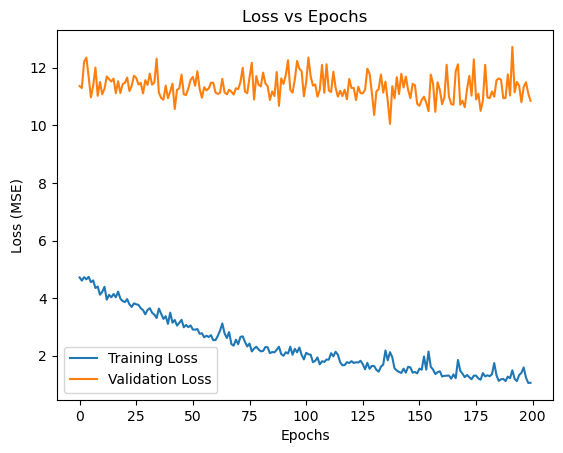

In [43]:
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

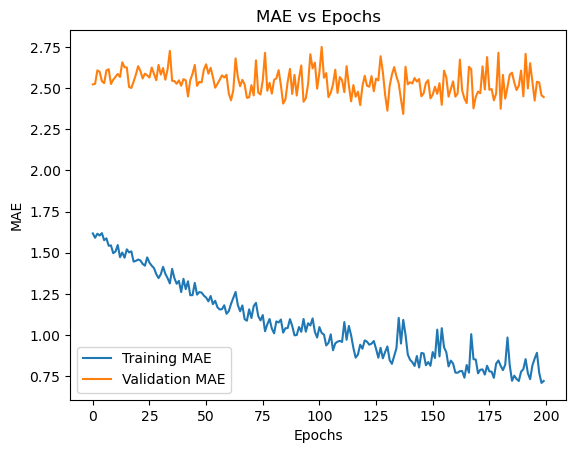

In [45]:
plt.figure()
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

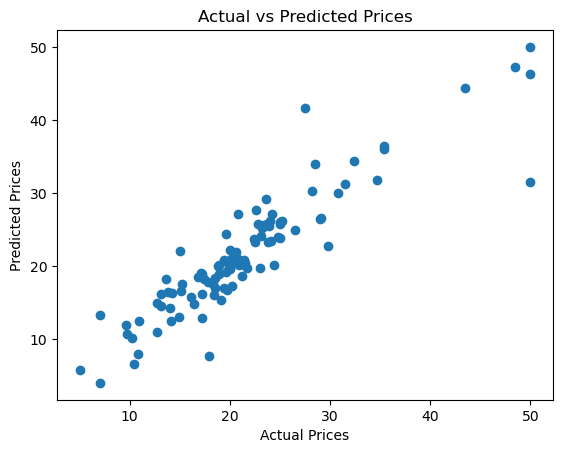

In [47]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

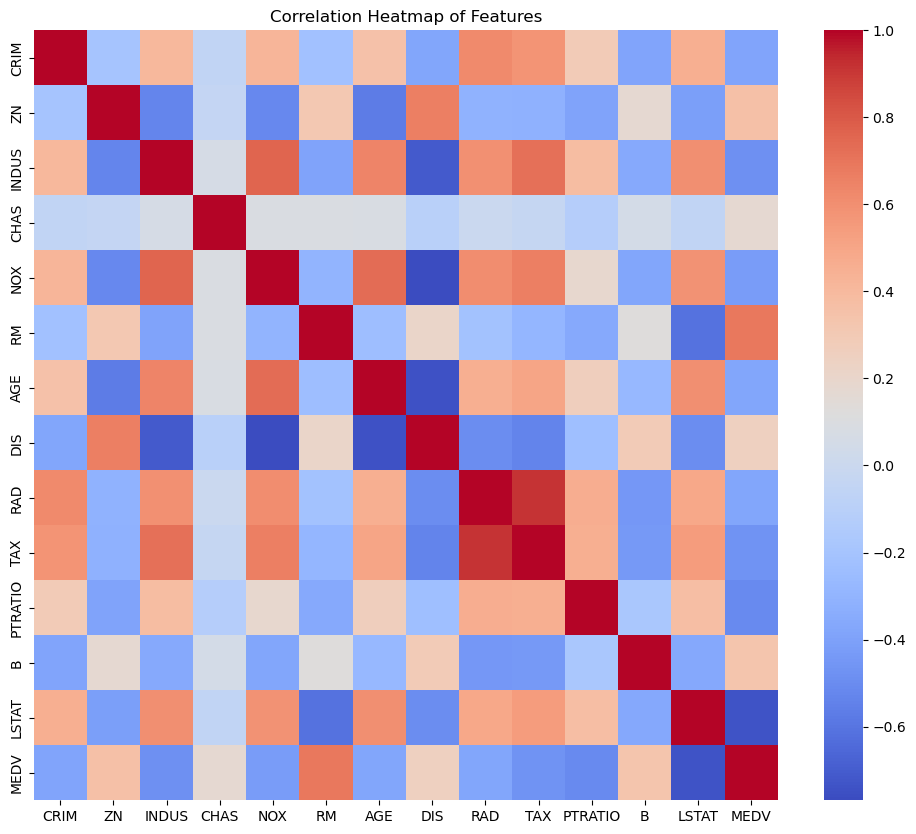

In [53]:
import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap of Features")
plt.show()